In [244]:
# !pip install openpyxl
# !pip install pandas
# !pip install keras-tuner

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras import layers, models
from keras.models import Sequential, Model, load_model
from keras.layers import Reshape, Dense, Input
from sklearn.model_selection import train_test_split
import keras_tuner as kt
from keras.utils import plot_model
import pandas as pd


I0000 00:00:1782563172.258965  648934 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782563173.106670  648934 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782563176.607625  648934 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [4]:
data_folder = "/home/sputnik/main/MyFolder/DL_Practice/prob1_data" 
output_file = data_folder + "/output.xlsx"
stress_folder = data_folder + "/stress"


In [5]:
X_df = pd.read_excel(output_file, header=None)

X_df = X_df.dropna(axis=0, how="all")
X_df = X_df.dropna(axis=1, how="all")

X = X_df.values.astype(float)

print("Shape of X:", X.shape)


Shape of X: (5000, 226)


In [6]:
num_samples = X.shape[0]

y = []

for i in range(num_samples):
    stress_file = stress_folder + "/stress_" + str(i) + ".txt"
    
    stress_data = np.loadtxt(stress_file)
    
    von_mises_stress = stress_data[:, 0]
    max_stress = np.max(von_mises_stress)
    
    y.append(max_stress)

y = np.array(y).reshape(-1, 1)

print("Shape of y:", y.shape)
print("Minimum max stress:", np.min(y))
print("Maximum max stress:", np.max(y))
print("Mean max stress:", np.mean(y))


Shape of y: (5000, 1)
Minimum max stress: 4412533.22285112
Maximum max stress: 43744146.8480609
Mean max stress: 9497545.137606278


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


X_train: (4000, 226)
X_test: (1000, 226)
y_train: (4000, 1)
y_test: (1000, 1)


In [8]:
X_mean = np.mean(X_train, axis=0)
X_std = np.std(X_train, axis=0)
X_std[X_std == 0] = 1

y_mean = np.mean(y_train, axis=0)
y_std = np.std(y_train, axis=0)

X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

y_train_scaled = (y_train - y_mean) / y_std
y_test_scaled = (y_test - y_mean) / y_std


In [9]:
def r2metric(y_true, y_pred):
    ss_res = tf.reduce_sum(tf.square(y_true - y_pred))
    ss_tot = tf.reduce_sum(tf.square(y_true - tf.reduce_mean(y_true)))
    return 1 - ss_res / (ss_tot + tf.keras.backend.epsilon())


In [10]:
tf.keras.backend.clear_session()

model1 = Sequential()

model1.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],),
                 kernel_initializer=keras.initializers.HeNormal()))
model1.add(layers.Dropout(0.1))
model1.add(Dense(64, activation='relu',
                 kernel_initializer=keras.initializers.HeNormal()))
model1.add(layers.Dropout(0.1))
model1.add(Dense(16, activation='relu',
                 kernel_initializer=keras.initializers.HeNormal()))

model1.add(Dense(1, name="Output"))

model1.summary()


/home/sputnik/miniconda3/envs/tf-gpu/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
W0000 00:00:1782563250.751978  648934 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        14,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,745 (77.13 KB)

 Trainable params: 19,745 (77.13 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model1.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='mse',
    metrics=[r2metric, 'mape']
)

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=25,
    restore_best_weights=True
)

history = model1.fit(
    X_train_scaled,
    y_train_scaled,
    epochs=200,
    batch_size=16,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.0959 - mape: 331.0637 - r2metric: -0.3729 - val_loss: 0.9149 - val_mape: 271.6909 - val_r2metric: 0.0928
Epoch 2/200
200/200 ━━━━━━━━━━━━━━━━━━━━ -1s -7095us/step - loss: 0.7928 - mape: 304.8622 - r2metric: 0.0217 - val_loss: 0.7705 - val_mape: 238.1984 - val_r2metric: 0.2285
Epoch 3/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.5763 - mape: 307.6503 - r2metric: 0.2932 - val_loss: 0.6292 - val_mape: 301.4150 - val_r2metric: 0.3239
Epoch 4/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.4368 - mape: 270.0306 - r2metric: 0.3992 - val_loss: 0.6465 - val_mape: 269.9446 - val_r2metric: 0.3561
Epoch 5/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.3520 - mape: 309.1045 - r2metric: 0.5071 - val_loss: 0.5741 - val_mape: 258.9743 - val_r2metric: 0.3664
Epoch 6/200
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2837 - mape: 254.5351 - r2metric: 0.5972 - val_loss: 0.5419 - val_mape: 277.0034 - val_r2metric:

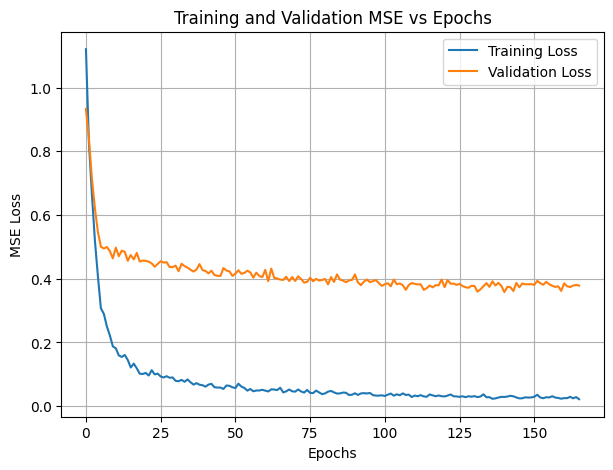

In [254]:
plt.figure(figsize=(7, 5))
plt.plot(history.history['loss'], label="Training Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.title("Training and Validation MSE vs Epochs")
plt.legend()
plt.grid(True)
plt.show()


In [255]:
test_loss, test_r2, test_mape = model1.evaluate(
    X_test_scaled, y_test_scaled, verbose=0
)

print("Testing MSE on scaled data:", test_loss)
print("Testing R2 score:", test_r2)
print("Testing MAPE on scaled data:", test_mape)


Testing MSE on scaled data: 0.3128874599933624
Testing R2 score: 0.5831629037857056
Testing MAPE on scaled data: 157.54827880859375


In [256]:
y_test_pred_scaled = model1.predict(X_test_scaled, verbose=0)

y_test_pred = y_test_pred_scaled * y_std + y_mean

mse_actual = np.mean((y_test - y_test_pred)**2)
mape_actual = np.mean(np.abs((y_test - y_test_pred) / y_test)) * 100

ss_res = np.sum((y_test - y_test_pred)**2)
ss_tot = np.sum((y_test - np.mean(y_test))**2)
r2_actual = 1 - ss_res / ss_tot

print("Testing MSE in actual stress scale:", mse_actual)
print("Testing MAPE (%):", mape_actual)
print("Testing R2 score:", r2_actual)


Testing MSE in actual stress scale: 5087005264053.254
Testing MAPE (%): 13.264385222953207
Testing R2 score: 0.6174769347025304


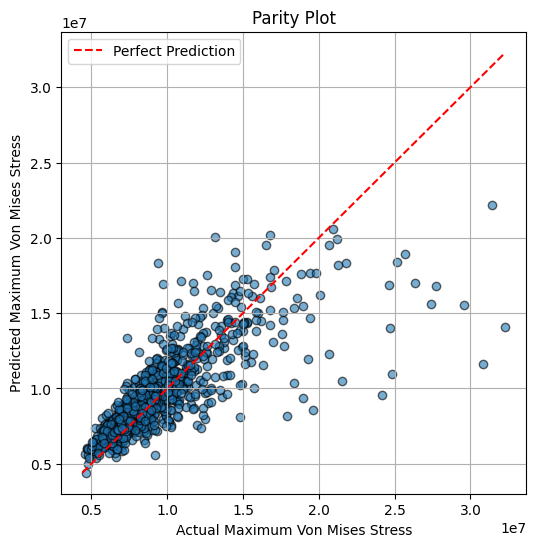

In [257]:
plt.figure(figsize=(6, 6))

plt.scatter(y_test, y_test_pred, alpha=0.6, edgecolor="black")

min_val = min(np.min(y_test), np.min(y_test_pred))
max_val = max(np.max(y_test), np.max(y_test_pred))

plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="Perfect Prediction")

plt.xlabel("Actual Maximum Von Mises Stress")
plt.ylabel("Predicted Maximum Von Mises Stress")
plt.title("Parity Plot")
plt.legend()
plt.grid(True)
plt.show()


In [272]:
num_design_variables = X_train.shape[1]

# Bounds from training data
x_min = np.min(X_train, axis=0).reshape(1, -1).astype(np.float32)
x_max = np.max(X_train, axis=0).reshape(1, -1).astype(np.float32)

# Avoid zero division
x_range = x_max - x_min
x_range[x_range == 0] = 1.0

# Target volume fraction in normalized 0 to 1 design space
VF_target = 0.3

eta = 0.001
N = 1000
tolerance = 1e-5

lambda_smooth = 0.001
lambda_low_stress = 1000.0

y_min_physical = np.min(y_train)

print("Number of design variables:", num_design_variables)
print("Target normalized volume fraction:", VF_target)
print("Minimum FEM training stress:", y_min_physical)


Number of design variables: 226
Target normalized volume fraction: 0.3
Minimum FEM training stress: 4412533.22285112


In [273]:
# Start from a feasible normalized design, not raw thickness
z_init = VF_target * np.ones((1, num_design_variables), dtype=np.float32)

z = tf.Variable(z_init, dtype=tf.float32)

X_mean_tf = tf.constant(X_mean.reshape(1, -1), dtype=tf.float32)
X_std_tf = tf.constant(X_std.reshape(1, -1), dtype=tf.float32)

y_mean_tf = tf.constant(y_mean.reshape(1, -1), dtype=tf.float32)
y_std_tf = tf.constant(y_std.reshape(1, -1), dtype=tf.float32)

x_min_tf = tf.constant(x_min, dtype=tf.float32)
x_range_tf = tf.constant(x_range, dtype=tf.float32)

y_min_tf = tf.constant(y_min_physical, dtype=tf.float32)

print("Initial normalized volume fraction:", tf.reduce_mean(z).numpy())


Initial normalized volume fraction: 0.29999998


In [274]:
# Convert normalized z to actual physical thickness x
x_initial = x_min_tf + z * x_range_tf

x_initial_scaled = (x_initial - X_mean_tf) / X_std_tf

initial_stress_scaled = model1(x_initial_scaled)
initial_stress = initial_stress_scaled * y_std_tf + y_mean_tf

print("Initial predicted stress:", initial_stress.numpy()[0][0])
print("Initial normalized volume fraction:", tf.reduce_mean(z).numpy())
print("Initial mean physical thickness:", tf.reduce_mean(x_initial).numpy())


Initial predicted stress: 15567858.0
Initial normalized volume fraction: 0.29999998
Initial mean physical thickness: 0.00074000005


In [275]:
stress_history = []
volume_history = []

previous_stress = None

for k in range(N):

    with tf.GradientTape() as tape:
        tape.watch(z)

        # Convert normalized design z to physical thickness x
        x_physical = x_min_tf + z * x_range_tf

        # Scale before NN
        x_scaled = (x_physical - X_mean_tf) / X_std_tf

        # Predict stress
        sigma_scaled = model1(x_scaled)
        sigma = sigma_scaled * y_std_tf + y_mean_tf

        # Smoothness penalty
        smoothness = tf.reduce_mean(tf.square(z[:, 1:] - z[:, :-1]))

        # Penalty if predicted stress goes below FEM training minimum
        low_stress_penalty = tf.square(tf.nn.relu(y_min_tf - sigma[0, 0]))

        # Objective
        J = sigma[0, 0] + lambda_smooth * smoothness + lambda_low_stress * low_stress_penalty

    # Gradient dJ/dz
    g = tape.gradient(J, z)

    # Normalize gradient for stability
    g = g / (tf.reduce_max(tf.abs(g)) + 1e-8)

    # Gradient descent update
    z_new = z - eta * g

    # Bounds in normalized space
    z_new = tf.clip_by_value(z_new, 0.0, 1.0)

    # Enforce normalized volume fraction
    z_new = z_new * (VF_target / tf.reduce_mean(z_new))

    # Clip again
    z_new = tf.clip_by_value(z_new, 0.0, 1.0)

    # Re-enforce volume fraction approximately
    z_new = z_new * (VF_target / tf.reduce_mean(z_new))
    z_new = tf.clip_by_value(z_new, 0.0, 1.0)

    z.assign(z_new)

    current_stress = sigma.numpy()[0][0]
    current_vf = tf.reduce_mean(z).numpy()

    stress_history.append(current_stress)
    volume_history.append(current_vf)

    if k % 50 == 0:
        print("Iteration:", k)
        print("Predicted stress:", current_stress)
        print("Normalized volume fraction:", current_vf)
        print()

    if previous_stress is not None:
        if abs(previous_stress - current_stress) < tolerance:
            print("Converged at iteration:", k)
            break

    previous_stress = current_stress


Iteration: 0
Predicted stress: 15567858.0
Normalized volume fraction: 0.3



Iteration: 50
Predicted stress: 13780882.0
Normalized volume fraction: 0.3

Iteration: 100
Predicted stress: 12373346.0
Normalized volume fraction: 0.3

Iteration: 150
Predicted stress: 11313743.0
Normalized volume fraction: 0.3

Iteration: 200
Predicted stress: 10293186.0
Normalized volume fraction: 0.3

Iteration: 250
Predicted stress: 9213414.0
Normalized volume fraction: 0.29999998

Iteration: 300
Predicted stress: 8403662.0
Normalized volume fraction: 0.3

Iteration: 350
Predicted stress: 7865686.0
Normalized volume fraction: 0.3

Iteration: 400
Predicted stress: 7598207.0
Normalized volume fraction: 0.3

Iteration: 450
Predicted stress: 7337963.0
Normalized volume fraction: 0.29999998

Iteration: 500
Predicted stress: 6965557.0
Normalized volume fraction: 0.3

Iteration: 550
Predicted stress: 6589802.0
Normalized volume fraction: 0.3

Iteration: 600
Predicted stress: 6201125.0
Normalized volume fraction: 0.29999998

Iteration: 650
Predicted stress: 5815326.0
Normalized volume fra

In [276]:
z_optimized = z.numpy()

x_optimized = x_min + z_optimized * x_range

x_optimized_scaled = (x_optimized - X_mean) / X_std

optimized_stress_scaled = model1.predict(x_optimized_scaled, verbose=0)
optimized_stress = optimized_stress_scaled * y_std + y_mean

print("Initial predicted stress:", initial_stress.numpy()[0][0])
print("Optimized predicted stress:", optimized_stress[0][0])
print("Minimum FEM training stress:", np.min(y_train))

print("Final normalized volume fraction:", np.mean(z_optimized))
print("Final mean physical thickness:", np.mean(x_optimized))

print("Minimum optimized thickness:", np.min(x_optimized))
print("Maximum optimized thickness:", np.max(x_optimized))

if optimized_stress[0][0] < np.min(y_train):
    print("Warning: optimized stress is below the minimum FEM training stress. Treat as surrogate extrapolation.")
else:
    print("Optimized stress is within the FEM training stress range.")


Initial predicted stress: 15567858.0
Optimized predicted stress: 4418916.482212444
Minimum FEM training stress: 4412533.22285112
Final normalized volume fraction: 0.3
Final mean physical thickness: 0.00074000005
Minimum optimized thickness: 0.00044814544
Maximum optimized thickness: 0.0019981938
Optimized stress is within the FEM training stress range.


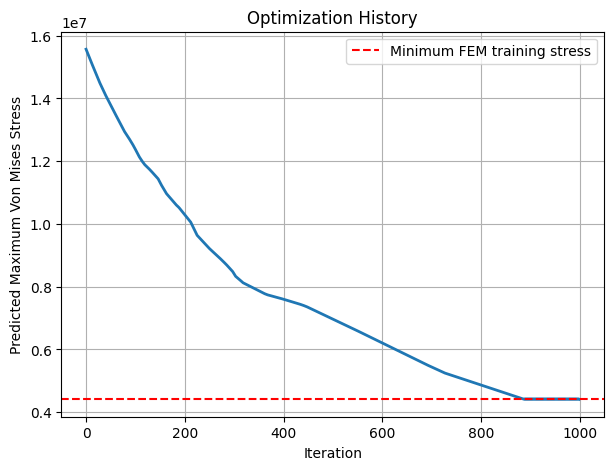

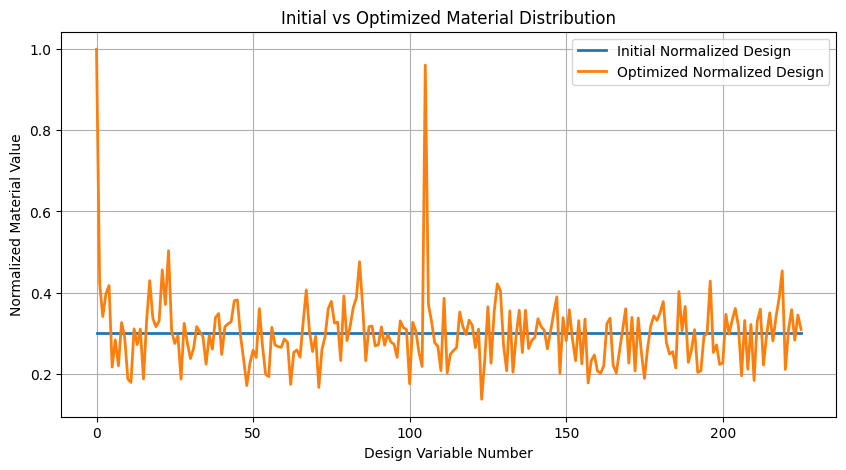

In [277]:
plt.figure(figsize=(7, 5))
plt.plot(stress_history, linewidth=2)
plt.axhline(np.min(y_train), color="red", linestyle="--", label="Minimum FEM training stress")
plt.xlabel("Iteration")
plt.ylabel("Predicted Maximum Von Mises Stress")
plt.title("Optimization History")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(z_init.flatten(), label="Initial Normalized Design", linewidth=2)
plt.plot(z_optimized.flatten(), label="Optimized Normalized Design", linewidth=2)
plt.xlabel("Design Variable Number")
plt.ylabel("Normalized Material Value")
plt.title("Initial vs Optimized Material Distribution")
plt.legend()
plt.grid(True)
plt.show()
